In [44]:
import jax.numpy as jnp
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dataclasses import dataclass
import jaxtyping
import cmcrameri.cm as cmc

# we want to use 64 bit floating precision
import jax
from jax import random, vmap
from jax.scipy import stats
from jax.scipy.optimize import minimize as minimize_jax
from scipy.optimize import minimize as minimize_scipy

jax.config.update("jax_enable_x64", True)

sns.set_style("darkgrid")

In [2]:

@dataclass(slots=True)
class StatefulRNGKey:
    key: jaxtyping.Key

    def __init__(self, key: jaxtyping.Key | int):
        if isinstance(key, int):
            key = jax.random.PRNGKey(key)

        self.key = key

    def shaped(self, shape: tuple[int, ...]):
        num_new_keys = jnp.prod(jnp.array(shape)) + 1
        new_keys = jax.random.split(self.key, num=num_new_keys)

        self.key = new_keys[0]
        return new_keys[1:].reshape((*shape, *new_keys.shape[1:]))

    def __call__(self, n: int | None = None):
        if n is None:
            self.key, subkey = jax.random.split(self.key)
            return subkey

        new_keys = jax.random.split(self.key, num=n + 1)
        self.key = new_keys[0]
        return new_keys[1:]


In [3]:
OUTPUT_DIR = (Path().resolve() / "..").resolve() / "report" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

A4_WIDTH_IN = 8.27

EXPORT_KWARGS = {
    "dpi": 600,
    "bbox_inches": "tight",
}


def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax, orientation="vertical")


def generate_samples(key, m, K, num_samples, jitter=0):
    """returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.


    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)

    returns
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################

    N = len(K)
    L = jnp.linalg.cholesky(K + jitter * jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)

    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), (
        f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    )
    return f_samples


In [4]:
skey = StatefulRNGKey(0)

x_data = jnp.asarray([9.589, 7.375, 4.647, 2.501, 2.538, 6.783, 4.294, 5.111, 0.130, 0.783])
y_data = jnp.asarray([3.032, 3.349, 2.906, 2.126, 1.538, 2.787, 3.078, 2.993, 0.828, -0.331])

beta = 4.0
tau = 2.0



## 2.1

In [5]:
N_w = 2
def prior(key, tau):
    mean = jnp.zeros(N_w)
    cov = tau**2 * jnp.eye(N_w)
    return random.multivariate_normal(key, mean, cov)

def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

def f(x, w):
    return w[1] * sigmoid(x + w[0])

In [6]:
key = random.PRNGKey(0)

S = 100
N_plot = 1000
x = jnp.linspace(0, 10, N_plot)

prior_realisations = vmap(prior, in_axes=(0, None))(skey.shaped((S,)), tau)
f_x_realisations = vmap(f, in_axes=(None, 0))(x, prior_realisations)



In [7]:
f_x_realisations.shape

(100, 1000)

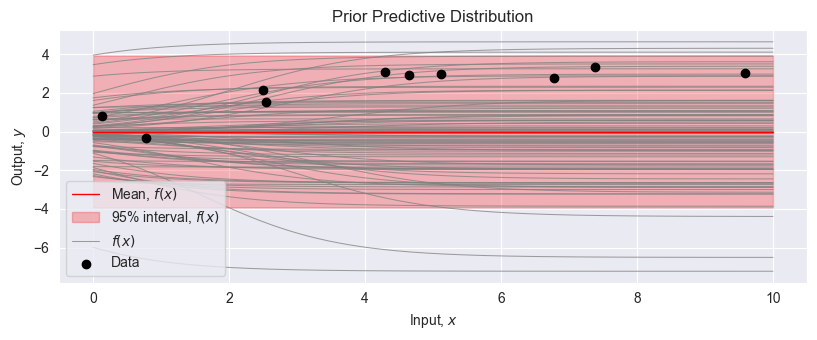

In [ ]:
fig, ax = plt.subplots(figsize=(A4_WIDTH_IN, 3.5))


mean_f_x = jnp.zeros_like(x)
p95_f_x = 1.96 * tau * jnp.ones_like(x)

plt.plot(x, jnp.zeros_like(x), c="red", lw=1, label="Mean, $f(x)$", zorder=3)
plt.fill_between(x, mean_f_x - p95_f_x, mean_f_x + p95_f_x, color="red", alpha=0.25, label="95% interval, $f(x)$")

lines = plt.plot(x, f_x_realisations.T, alpha=0.75, c="gray", lw=0.75)
lines[0].set_label("$f(x)$")
plt.scatter(x_data, y_data, label="Data", c="k", zorder=3)

plt.xlabel("Input, $x$")
plt.ylabel("Neural Network Output, $f(x)$")
plt.legend()
plt.title("Prior Predictive Distribution")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "2_1.png", **EXPORT_KWARGS)

## 2.3

In [9]:
def log_likelihood_joint(y, w, x, beta, tau):
    assert len(w) == 2
    assert y.shape == x.shape

    out = 0.0

    out += stats.norm.logpdf(w[0], loc=0.0, scale=tau)
    out += stats.norm.logpdf(w[1], loc=0.0, scale=tau)

    means = f(x, w)
    out += jnp.sum(stats.norm.logpdf(y, loc=means, scale=1.0 / jnp.sqrt(beta)))

    return out

w_2_3 = jnp.array([0.0, 0.0])

log_likelihood_joint(y_data, w_2_3, x_data, beta, tau)

Array(-130.94934095, dtype=float64)

## 2.5

In [10]:
def sigmoid_prime(x):
    s = sigmoid(x)
    return s * (1 - s)

def sigmoid_prime_prime(x):
    s = sigmoid(x)
    sp = sigmoid_prime(x)
    return (1 - 2 * s) * sp

In [192]:
# From Exercise 2.4
def gradient(x, y, w, beta, tau):
    assert len(w) == 2
    assert y.shape == x.shape

    w0 = w[0]
    w1 = w[1]
    inner = x + w0
    residual = y - w1 * sigmoid(inner)



    grad_w0 = -w0 / tau**2
    grad_w0 += beta * w1 * jnp.sum(residual * sigmoid_prime(inner))

    grad_w1 = -w1 / tau**2
    grad_w1 += beta * jnp.sum(residual * sigmoid(inner))

    return jnp.array([grad_w0, grad_w1])

def hessian(x, y, w, beta, tau):
    assert len(w) == 2
    assert y.shape == x.shape

    w0 = w[0]
    w1 = w[1]
    inner = x + w0
    residual = y - w1 * sigmoid(inner)

    H_00 = -1 / tau**2
    H_00 += beta * w1 * jnp.sum(-w1 * (sigmoid_prime(inner)) ** 2 + residual * sigmoid_prime_prime(inner))

    H_11 = -1 / tau**2
    H_11 += beta * jnp.sum(-sigmoid(inner)**2)

    H_01 = beta * jnp.sum((y - 2 * w1 * sigmoid(inner)) * sigmoid_prime(inner))
    H_10 = H_01

    H = jnp.array([[H_00, H_01], [H_10, H_11]])
    return H

# We can find MAP by optimising this
results_analytical = minimize_scipy(
    lambda w: -log_likelihood_joint(y_data, w, x_data, beta, tau),
    jac=lambda w: -gradient(x_data, y_data, w, beta, tau),
    x0=jnp.zeros(2),
)

w_MAP = results_analytical.x

H = hessian(x_data, y_data, w_MAP, beta, tau)
H

display(results_analytical)
display(w_MAP)
display(H)
display(-jnp.linalg.inv(H))

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 10.409622395739989
        x: [-2.204e+00  3.104e+00]
      nit: 9
      jac: [ 2.930e-09 -1.737e-09]
 hess_inv: [[ 1.677e-01 -4.599e-02]
            [-4.599e-02  5.233e-02]]
     nfev: 12
     njev: 12

array([-2.20442705,  3.10426822])

Array([[ -7.85402077,  -6.89708646],
       [ -6.89708646, -25.14344258]], dtype=float64)

Array([[ 0.16772658, -0.046009  ],
       [-0.046009  ,  0.05239251]], dtype=float64)

## 2.6

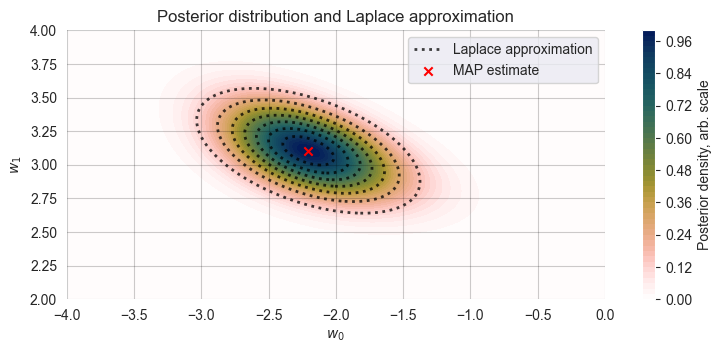

In [ ]:
N_plot = 1000
w_0_points = jnp.linspace(-4, 0, N_plot)
w_1_points = jnp.linspace(2, 4, N_plot)
W_0, W_1 = jnp.meshgrid(w_0_points, w_1_points)

W_flat = jnp.column_stack([W_0.ravel(), W_1.ravel()])

vmap_likelihood = jax.vmap(lambda w: log_likelihood_joint(y_data, w, x_data, beta, tau))
log_likelihood_flat = vmap_likelihood(W_flat)
log_likelihood_grid = log_likelihood_flat.reshape(W_0.shape)
posterior_grid = jnp.exp(log_likelihood_grid - jnp.max(log_likelihood_grid))

fig, ax = plt.subplots(figsize=(A4_WIDTH_IN, 3.5))
im = ax.contourf(W_0, W_1, posterior_grid, levels=50, cmap=cmc.batlowW_r)
plt.colorbar(im, ax=ax, label="Posterior density, arb. scale")
ax.set_aspect("equal")

# Plot Laplace approx
laplace_pdf = stats.multivariate_normal.pdf(W_flat, mean=w_MAP, cov=-jnp.linalg.inv(H))
laplace_grid = laplace_pdf.reshape(W_0.shape)
ax.contour(W_0, W_1, laplace_grid, levels=7, colors='black', alpha=0.75, linewidths=2.0, linestyles="dotted")
ax.plot([], [], color='black', alpha=0.75, linewidth=2.0, linestyle="dotted", label="Laplace approximation")

# Plot MAP estimate
plt.scatter(w_MAP[0], w_MAP[1], c="red", label="MAP estimate", marker="x", zorder=3)

ax.set_xlabel("$w_0$")
ax.set_ylabel("$w_1$")
ax.set_aspect("equal")

ax.grid(True, color="black", alpha=0.2)
ax.set_axisbelow(False)

plt.title("Posterior distribution and Laplace approximation")
plt.legend()

# Save BEFORE show
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "2_6.png", **EXPORT_KWARGS)

## 2.7

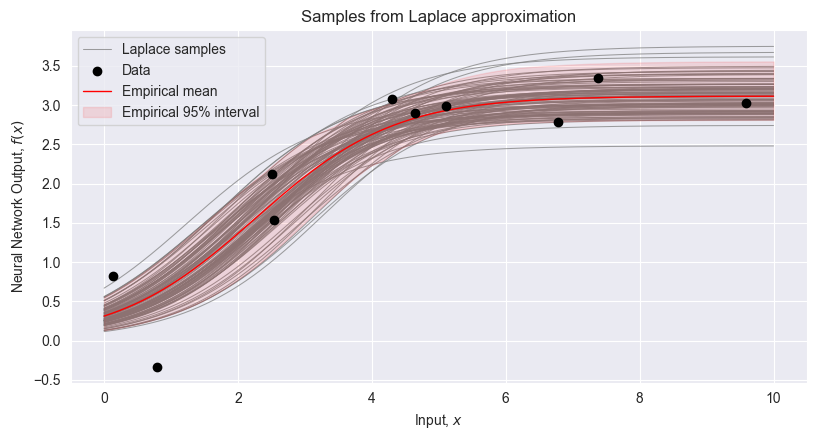

In [207]:
S = 100

w_samples_laplace = random.multivariate_normal(key=skey(), mean=w_MAP, cov=-jnp.linalg.inv(H), shape=(S,))
w_samples_laplace.shape

x = jnp.linspace(0, 10, N_plot)
f_x_laplace_samples = vmap(lambda w: f(x, w))(w_samples_laplace)
f_x_laplace_samples.shape

mean = jnp.mean(f_x_laplace_samples, axis=0)
ci_lower = jnp.percentile(f_x_laplace_samples, 2.5, axis=0)
ci_upper = jnp.percentile(f_x_laplace_samples, 97.5, axis=0)

plt.figure(figsize=(A4_WIDTH_IN, 4.5))
lines = plt.plot(x, f_x_laplace_samples.T, alpha=0.75, c="gray", lw=0.75)
# Add label for the first line only
lines[0].set_label("Laplace samples")

plt.scatter(x_data, y_data, label="Data", c="k", zorder=5)

plt.plot(x, mean, c="red", lw=1, label="Empirical mean")
plt.fill_between(x, ci_lower, ci_upper, color="red", zorder=3, alpha=0.1, label="Empirical 95% interval")

plt.legend()
plt.xlabel("Input, $x$")
plt.ylabel("Neural Network Output, $f(x)$")
plt.title("Samples from Laplace approximation")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "2_7.png", **EXPORT_KWARGS)

## 2.8

In [ ]:
S_stat = 100000
w_samples_stat = random.multivariate_normal(key=skey(), mean=w_MAP, cov=-jnp.linalg.inv(H), shape=(S_stat,))

x_stat = 8.0
f_x_stat_samples = vmap(lambda w: f(x_stat, w))(w_samples_stat)
f_x_stat_samples.shape

task_2_8_answer = jnp.mean(f_x_stat_samples > 3.0)
print(f"Estimated probability that f(8.0) > 3.0 under the Laplace approximation: {task_2_8_answer:.4f}")

Estimated probability that f(8.0) > 3.0 under the Laplace approximation: 0.6611


## 2.9

In [206]:
x_star = 3.75
w_samples_star = random.multivariate_normal(key=skey(), mean=w_MAP, cov=-jnp.linalg.inv(H), shape=(S_stat,))
f_x_star_samples = vmap(lambda w: f(x_star, w))(w_samples_star)
noise = random.normal(key=skey(), shape=(S_stat,)) / jnp.sqrt(beta)
y_star_samples = f_x_star_samples + noise

task_2_9_mean = jnp.mean(y_star_samples)
task_2_9_ci_lower = jnp.percentile(y_star_samples, 2.5)
task_2_9_ci_upper = jnp.percentile(y_star_samples, 97.5)

print(f"Estimated mean of y* given x*={x_star} under the Laplace approximation: {task_2_9_mean:.4f}")
print(f"Estimated 95% credible interval for y* given x*={x_star}: [{task_2_9_ci_lower:.4f}, {task_2_9_ci_upper:.4f}]")

Estimated mean of y* given x*=3.75 under the Laplace approximation: 2.5266
Estimated 95% credible interval for y* given x*=3.75: [1.4723, 3.5808]


In [196]:
f_x_star_samples.shape

(100000,)